In [ ]:
# ==========================================
# STEP 1: Import Required Libraries
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
!pip install category_encoders --quiet
from category_encoders import TargetEncoder

# ==========================================
# STEP 2: Load Dataset
# ==========================================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("UCI_Credit_Card.csv")
print("✅ Dataset loaded successfully! Shape:", df.shape)

# ==========================================
# STEP 3: Basic Cleaning
# ==========================================
# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ==========================================
# STEP 4: Softer Outlier Removal
# ==========================================
num_cols = [
    'LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

for col in num_cols:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    df = df[(df[col] >= Q1) & (df[col] <= Q3)]

print("✅ Cleaning Complete. Shape:", df.shape)

# ==========================================
# STEP 5: Feature Engineering
# ==========================================
# Ensure target column name consistency
target_col = 'default.payment.next.month'

# Binary encoding for categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])

# Target Encoding for multi-category columns
multi_cat_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() > 2]
if multi_cat_cols:
    te = TargetEncoder(cols=multi_cat_cols)
    df[multi_cat_cols] = te.fit_transform(df[multi_cat_cols], df[target_col])

print("✅ Feature Engineering Complete")

# ==========================================
# STEP 6: Split Features and Target
# ==========================================
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nBefore Resampling:\n", y.value_counts())

# ==========================================
# STEP 7: Handle Class Imbalance (SMOTE + Tomek)
# ==========================================
if len(y.unique()) > 1:
    smt = SMOTETomek(random_state=42)
    X_res, y_res = smt.fit_resample(X, y)
    print("\n✅ After Resampling:\n", y_res.value_counts())
else:
    print("\n⚠️ SMOTE not applied — target has only one class!")

# ==========================================
# STEP 8: Normalize Data
# ==========================================
scaler = StandardScaler()

if len(y.unique()) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n✅ Normalization Done")
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================================
# STEP 9: Final Verification
# ==========================================
print("\n✅ Preprocessing Pipeline Completed Successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.9 MB/s eta 0:00:00


Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv
✅ Dataset loaded successfully! Shape: (30000, 25)


/tmp/ipython-input-2833165386.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


✅ Cleaning Complete. Shape: (13241, 25)
✅ Feature Engineering Complete

Before Resampling:
 default.payment.next.month
0    9704
1    3537
Name: count, dtype: int64

✅ After Resampling:
 default.payment.next.month
1    9293
0    9293
Name: count, dtype: int64

✅ Normalization Done
Train Shape: (14868, 24)
Test Shape: (3718, 24)

✅ Preprocessing Pipeline Completed Successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:10:46] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:10:46] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost Results:
Accuracy: 80.88 %

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82      1859
           1       0.83      0.77      0.80      1859

    accuracy                           0.81      3718
   macro avg       0.81      0.81      0.81      3718
weighted avg       0.81      0.81      0.81      3718



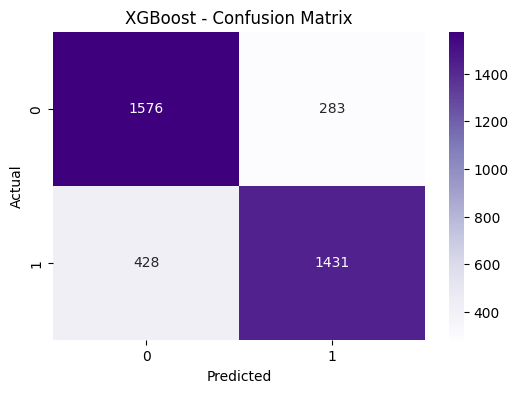

In [ ]:
# ==========================================
# XGBoost Classifier
# ==========================================

!pip install xgboost --quiet
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Train XGBoost Model (GPU Compatible)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',  # Use GPU if available (tree_method='gpu_hist')
    device='cuda'        # optional for GPU
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("✅ XGBoost Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/tmp/ipython-input-2050158511.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df_xgb, palette='Purples_d')


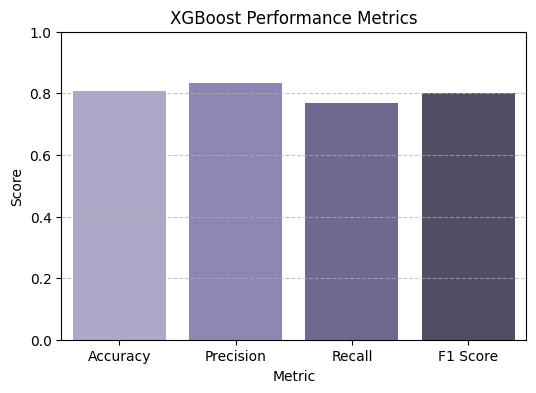

In [ ]:
# ==========================================
# 📊 XGBoost Performance Metrics Visualization
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metrics_xgb = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb)
}

metrics_df_xgb = pd.DataFrame(list(metrics_xgb.items()), columns=['Metric', 'Score'])

plt.figure(figsize=(6, 4))
sns.barplot(x='Metric', y='Score', data=metrics_df_xgb, palette='Purples_d')
plt.title('XGBoost Performance Metrics')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



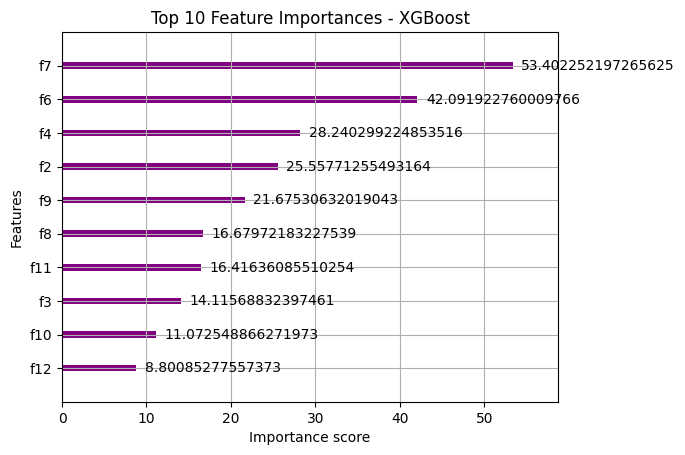

In [ ]:
# ==========================================
# XGBoost Feature Importance Visualization
# ==========================================
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Plot the top 10 most important features
plot_importance(xgb_model, max_num_features=10, importance_type='gain', color='purple')
plt.title('Top 10 Feature Importances - XGBoost')
plt.show()



/tmp/ipython-input-3583684500.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Purples_d')


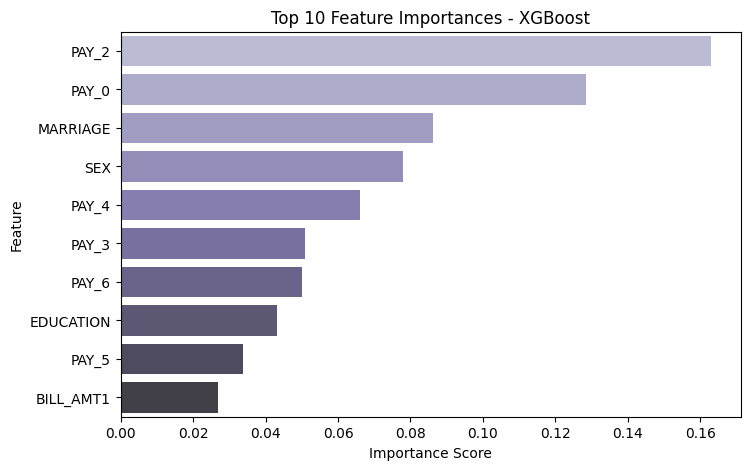

In [ ]:
import pandas as pd
import seaborn as sns

# Get feature importances
importances = xgb_model.feature_importances_
features = X.columns

# Create a DataFrame and sort
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

# Plot using seaborn
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Purples_d')
plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


In [ ]:
# ==========================================
# 🔍 Grid Search Optimization - XGBoost
# ==========================================
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',   # use 'gpu_hist' if GPU available
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("🚀 Running Grid Search for XGBoost...")
grid_xgb.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid_xgb.best_params_)
print("✅ Best Cross-Validation Accuracy:", round(grid_xgb.best_score_ * 100, 2), "%")

# Evaluate best model on test set
best_xgb = grid_xgb.best_estimator_
y_pred_gs_xgb = best_xgb.predict(X_test)
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_gs_xgb) * 100, 2), "%")


🚀 Running Grid Search for XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits

✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 1.0}
✅ Best Cross-Validation Accuracy: 82.1 %

Test Accuracy: 83.08 %


In [1]:
# ==========================================
# 📊 Classification Report for Best XGBoost Model
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix

print("📄 Classification Report for Best XGBoost Model:\n")
print(classification_report(y_test, y_pred_gs_xgb))

# Optional: confusion matrix
print("\n🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gs_xgb))


📄 Classification Report for Best XGBoost Model:



NameError: name 'y_test' is not defined

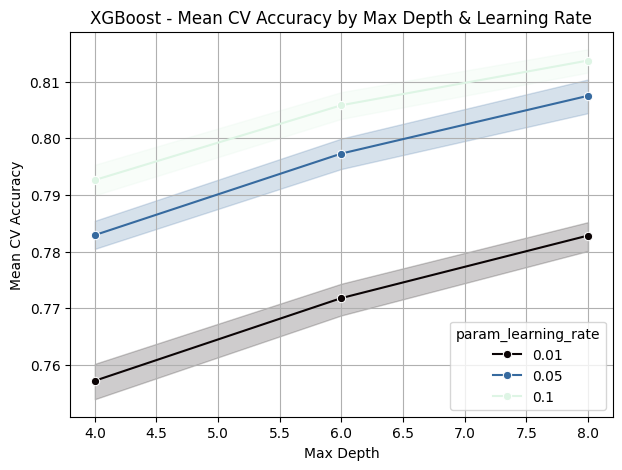

In [ ]:
# ==========================================
# 📊 Visualization — Mean CV Accuracy vs Max Depth
# ==========================================
results = pd.DataFrame(grid_xgb.cv_results_)
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=results,
    x='param_max_depth',
    y='mean_test_score',
    hue='param_learning_rate',
    marker='o',
    palette='mako'
)
plt.title("XGBoost - Mean CV Accuracy by Max Depth & Learning Rate")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)
plt.show()

should work


In [ ]:
# ======================================================================
#                 FULL PIPELINE — CLEANED + CORRECTED
#    Preprocessing → Feature Selection → Resampling → XGBoost → GridSearchCV
# ======================================================================

# ------------------------------------------------------
# INSTALL REQUIRED PACKAGES
# ------------------------------------------------------
!pip install imbalanced-learn --quiet
!pip install xgboost --quiet

# ------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✓ All libraries loaded")


# ======================================================================
#  PART 1 — UPLOAD DATASET
# ======================================================================
from google.colab import files
print("📁 Upload your UCI_Credit_Card.csv file...")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"✓ Loaded: {file_name}")
print(df.head())


# ======================================================================
#  PART 2 — CLEANING + TARGET FIX
# ======================================================================

# Possible names for target column
possible_targets = [
    'default', 'default ', 'DEFAULT',
    'default.payment.next.month', 'default.payment.next.month '
]

target_col = None
for col in df.columns:
    if col in possible_targets:
        target_col = col
        break

if target_col is None:
    raise ValueError("❌ ERROR: Target column not found. Check your CSV.")

df.rename(columns={target_col: "default"}, inplace=True)
print(f"✓ Target column fixed: {target_col} → default")


# Remove ID column
if "ID" in df.columns:
    df.drop(columns="ID", inplace=True)
    print("✓ Dropped ID")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Missing value handling
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

if len(cat_cols) > 0:
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("✓ Missing values handled")

# Outlier clipping (NO ROW REMOVAL)
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df[num_cols] = df[num_cols].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("✓ Outliers clipped (no rows deleted)")


# ======================================================================
#  PART 3 — TRAIN–TEST SPLIT
# ======================================================================
X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class distribution:\n", y_train.value_counts())


# ======================================================================
#  PART 4 — BALANCING (Undersample → SMOTE-Tomek)
# ======================================================================

# Step 1 — Random undersampling (keep 70% ratio)
rus = RandomUnderSampler(sampling_strategy=0.7, random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Step 2 — SMOTE-Tomek
smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train_rus, y_train_rus)

print("\nAfter SMOTE-Tomek:\n", y_train_bal.value_counts())


# ======================================================================
#  PART 5 — FEATURE SELECTION (Filter → Wrapper)
# ======================================================================

# ------ Filter: Mutual Information ------
selector_filter = SelectKBest(mutual_info_classif, k=15)
X_train_filter = selector_filter.fit_transform(X_train_bal, y_train_bal)
X_test_filter = selector_filter.transform(X_test)

selected_filter = X.columns[selector_filter.get_support()].tolist()

print("\n✓ Filter-selected features:")
print(selected_filter)

# ------ Wrapper: RFE ------
estimator = LogisticRegression(max_iter=300)
rfe = RFE(estimator, n_features_to_select=10)
X_train_sel = rfe.fit_transform(X_train_filter, y_train_bal)
X_test_sel = rfe.transform(X_test_filter)

selected_final = [selected_filter[i] for i in range(len(selected_filter)) if rfe.support_[i]]

print("\n✓ Final selected features (10):")
print(selected_final)


# ======================================================================
#  PART 6 — SCALING
# ======================================================================
scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_sel)
X_test_final = scaler.transform(X_test_sel)

print("✓ Scaling complete")


# ======================================================================
#  PART 7 — XGBOOST MODEL
# ======================================================================

xgb = XGBClassifier(
    tree_method='hist',     # CPU-safe, fast
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_final, y_train_bal)
y_pred = xgb.predict(X_test_final)

print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred))


# ======================================================================
#  PART 8 — GRID SEARCH OPTIMIZATION
# ======================================================================

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 1],
    'subsample': [0.7, 1.0],
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_final, y_train_bal)

print("\nBEST PARAMETERS:")
print(grid.best_params_)

print("\nBEST CV ACCURACY:", grid.best_score_)

# Final prediction
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_final)

print("\nFINAL TEST ACCURACY:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

# CONFUSION MATRIX
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — XGBoost (Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


✓ All libraries loaded
📁 Upload your UCI_Credit_Card.csv file...


Saving UCI_Credit_Card.csv to UCI_Credit_Card (3).csv
✓ Loaded: UCI_Credit_Card (3).csv
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

ValueError: Must specify axis=0 or 1